# Chapter 8: Time-Series Analysis and Hypothesis Testing

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Normal, Student-t, F, and chi-square distributions
2. Confidence intervals and mean tests
3. Equal-variance and equal-mean tests
4. Durbin-Watson autocorrelation
5. Granger causality
6. Interpolation and calendar effects

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 8.1 Distribution Functions: PDF, CDF, and PPF

PDF measures density, CDF gives cumulative probability, and PPF is the inverse CDF used to obtain critical values.


### Structured Review

- **Object:** Identify the value and data type stored by each variable.
- **Access:** Remember that Python sequence indexing begins at zero.
- **Mutability:** Decide whether the object may be changed after creation.
- **Function contract:** Separate parameters, calculation steps, and the returned value.

### Exam Focus

- Preserve indentation inside functions and conditional blocks.
- Distinguish positional arguments from keyword arguments.
- Trace the value returned by a function for a small input.

### Common Mistakes

- Using the wrong capitalization in a variable name.
- Attempting to modify a tuple.
- Printing a result inside a function when the question requires `return`.


In [1]:
'''
本单元比较正态、t、F 和卡方分布的关键函数。
ppf 输入概率并返回临界值，是考试常见填空。
'''
from scipy import stats

alpha = 0.05

# 双侧 95% 正态置信区间使用 alpha/2 和 1-alpha/2
z_left = stats.norm.ppf(alpha / 2)
z_right = stats.norm.ppf(1 - alpha / 2)

# t 临界值还需要自由度参数
t_right = stats.t.ppf(1 - alpha / 2, df=29)

# F 检验通常使用右尾临界值
f_right = stats.f.ppf(1 - alpha, dfn=10, dfd=12)

# chi2 是卡方分布；不要误用 chi 分布
chi_right = stats.chi2.ppf(1 - alpha, df=4)

print("Normal critical values =", round(z_left, 4), round(z_right, 4))
print("Student-t critical value =", round(t_right, 4))
print("F critical value =", round(f_right, 4))
print("Chi-square critical value =", round(chi_right, 4))


Normal critical values = -1.96 1.96
Student-t critical value = 2.0452
F critical value = 2.7534
Chi-square critical value = 9.4877


**Result interpretation.** The t critical value is wider than the normal value because finite-sample uncertainty produces heavier tails.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

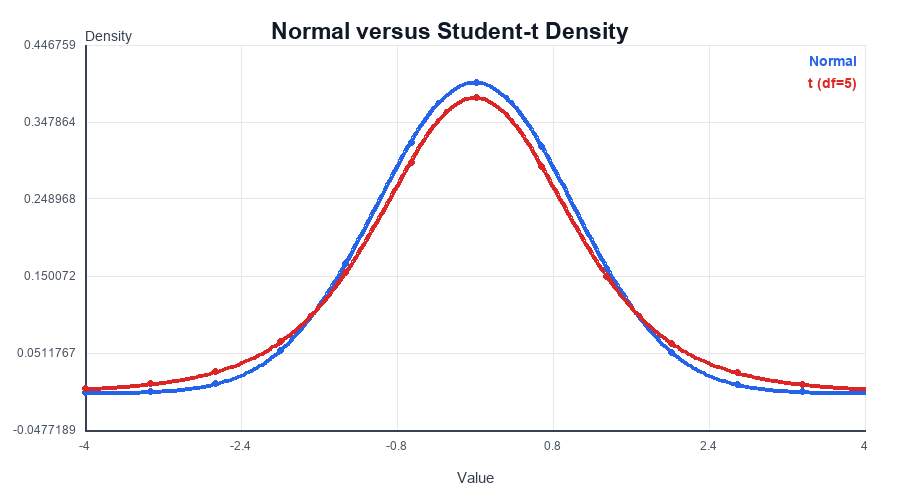


## 8.2 Confidence Interval for a Mean

When population volatility is unknown, use the sample standard deviation and a Student-t critical value.


### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [2]:
'''
本单元构造平均收益率的双侧 t 置信区间。
标准误等于样本标准差除以样本量平方根。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(802)
returns = rng.normal(0.0005, 0.012, 60)
alpha = 0.05
n = len(returns)
sample_mean = returns.mean()
sample_std = returns.std(ddof=1)

# 标准误衡量样本均值的抽样波动
standard_error = sample_std / np.sqrt(n)

# 双侧区间使用 1-alpha/2 分位数
t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
margin = t_critical * standard_error
lower, upper = sample_mean - margin, sample_mean + margin

print("Sample mean =", round(float(sample_mean), 6))
print("95% CI =", (round(float(lower), 6), round(float(upper), 6)))
print("Is zero inside? =", lower <= 0 <= upper)


Sample mean = 0.000909
95% CI = (-0.001694, 0.003511)
Is zero inside? = True


**Result interpretation.** If zero lies inside the interval, the data do not provide enough evidence that mean return differs from zero at the 5% level.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 8.3 Equal Variances and Equal Means

Levene's test evaluates equal variances. The variance result helps choose between the pooled and Welch two-sample t-tests.


### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [3]:
'''
本单元先检验方差，再检验均值。
Levene p 值较小时拒绝等方差假设，并优先使用 Welch t 检验。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(803)
asset_a = rng.normal(0.0010, 0.010, 120)
asset_b = rng.normal(0.0015, 0.016, 120)
alpha = 0.05

# Levene 检验 H0：两个总体方差相等
levene_result = stats.levene(asset_a, asset_b)
equal_variance = levene_result.pvalue >= alpha

# equal_var=False 对应 Welch t 检验
t_result = stats.ttest_ind(asset_a, asset_b, equal_var=equal_variance)

print("Levene p-value =", round(float(levene_result.pvalue), 6))
print("Assume equal variance? =", equal_variance)
print("Mean-test p-value =", round(float(t_result.pvalue), 6))


Levene p-value = 0.0
Assume equal variance? = False
Mean-test p-value = 0.063737


**Result interpretation.** Testing variance first prevents mechanically applying the pooled t-test when dispersion differs substantially.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 8.4 Durbin-Watson Autocorrelation Test

Durbin-Watson is approximately 2 without first-order autocorrelation, below 2 for positive autocorrelation, and above 2 for negative autocorrelation.


### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [4]:
'''
本单元直接实现 Durbin-Watson 统计量。
分子是相邻残差差值平方和，分母是残差平方和。
'''
import numpy as np

rng = np.random.default_rng(804)
errors = np.zeros(200)
for t in range(1, len(errors)):
    # 构造正自相关误差：当前误差依赖上一期误差
    errors[t] = 0.65 * errors[t - 1] + rng.normal(0, 1)

# np.diff 计算 e_t - e_(t-1)
durbin_watson = np.sum(np.diff(errors) ** 2) / np.sum(errors ** 2)

interpretation = (
    "positive autocorrelation" if durbin_watson < 1.5
    else "negative autocorrelation" if durbin_watson > 2.5
    else "weak or no autocorrelation"
)

print("Durbin-Watson =", round(float(durbin_watson), 4))
print("Interpretation =", interpretation)


Durbin-Watson = 0.7405
Interpretation = positive autocorrelation


**Result interpretation.** The simulated autoregressive errors should produce a statistic clearly below two.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

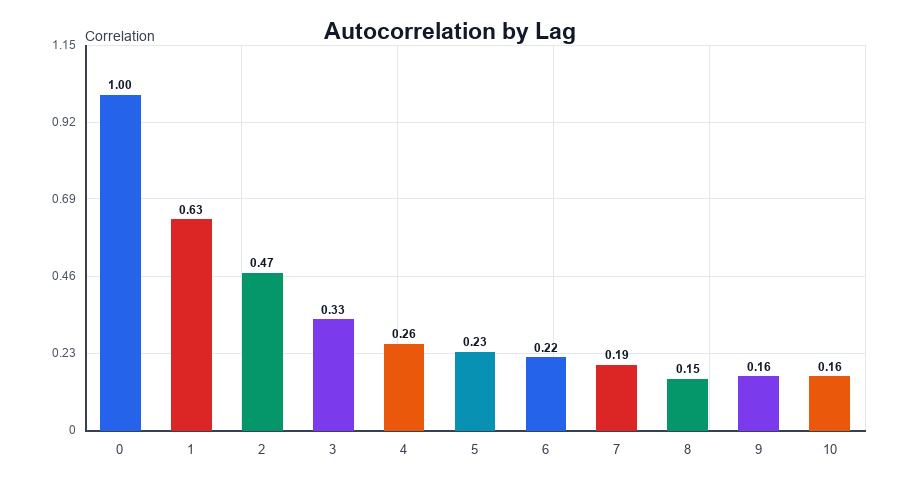


## 8.5 Granger Causality by Restricted and Unrestricted Models

X Granger-causes Y when lagged X values improve prediction of Y beyond lagged Y values. This is predictive precedence, not philosophical causation.


### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [5]:
'''
本单元比较受限模型与非受限模型的残差平方和，并计算 Granger F 统计量。
受限模型只含 y 的滞后项，非受限模型再加入 x 的滞后项。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(805)
n = 250
x = rng.normal(0, 1, n)
y = np.zeros(n)
for t in range(2, n):
    # y 同时受自身一期滞后和 x 一期滞后影响
    y[t] = 0.4 * y[t - 1] + 0.7 * x[t - 1] + rng.normal(0, 0.8)

target = y[2:]
y_lags = np.column_stack([y[1:-1], y[:-2]])
x_lags = np.column_stack([x[1:-1], x[:-2]])

# 受限模型：常数项 + y 的两个滞后
X_restricted = np.column_stack([np.ones(len(target)), y_lags])

# 非受限模型：再加入 x 的两个滞后
X_unrestricted = np.column_stack([X_restricted, x_lags])

resid_r = target - X_restricted @ np.linalg.lstsq(X_restricted, target, rcond=None)[0]
resid_u = target - X_unrestricted @ np.linalg.lstsq(X_unrestricted, target, rcond=None)[0]
rss_r = np.sum(resid_r**2)
rss_u = np.sum(resid_u**2)

# q 是新增的 x 滞后项数量
q = x_lags.shape[1]
df_denominator = len(target) - X_unrestricted.shape[1]
f_value = ((rss_r - rss_u) / q) / (rss_u / df_denominator)
p_value = 1 - stats.f.cdf(f_value, q, df_denominator)

print("Granger F-value =", round(float(f_value), 4))
print("p-value =", round(float(p_value), 8))
print("Conclusion =", "X Granger-causes Y" if p_value < 0.05 else "No evidence of Granger causality")


Granger F-value = 89.532
p-value = 0.0
Conclusion = X Granger-causes Y


**Result interpretation.** The unrestricted model should fit materially better because the data-generating process includes lagged X.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 8.6 Linear Interpolation and the January Effect

Interpolation estimates internal missing values. A calendar-effect test compares January returns with non-January returns.


### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [6]:
'''
本单元先对缺失序列做线性插值，再检验一月收益率是否不同。
插值只适用于内部缺口，不能替代对数据生成过程的判断。
'''
import numpy as np
from scipy import stats

series = np.array([1.0, 2.0, np.nan, np.nan, 6.0])
missing = np.isnan(series)

# np.interp 根据左右有效点对缺失位置进行线性插值
series[missing] = np.interp(
    np.flatnonzero(missing),
    np.flatnonzero(~missing),
    series[~missing],
)

rng = np.random.default_rng(806)
months = np.tile(np.arange(1, 13), 15)
monthly_returns = rng.normal(0.008, 0.04, len(months))
monthly_returns[months == 1] += 0.02

# 按月份标签拆分 January 与 non-January 样本
january = monthly_returns[months == 1]
non_january = monthly_returns[months != 1]
test = stats.ttest_ind(january, non_january, equal_var=False)

print("Interpolated series =", series)
print("January mean =", round(float(january.mean()), 4))
print("Non-January mean =", round(float(non_january.mean()), 4))
print("January-effect p-value =", round(float(test.pvalue), 6))


Interpolated series = [1.         2.         3.33333333 4.66666667 6.        ]
January mean = 0.0211
Non-January mean = 0.0103
January-effect p-value = 0.358656


**Result interpretation.** The statistical result depends on sampling variation even though the simulation adds a positive January premium.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 8.7 Manual F-Test for Equal Variances


The instructor demonstrates the classical F statistic as the larger sample
variance divided by the smaller sample variance, followed by comparison with a
right-tail critical value.



### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [7]:
'''
本单元补充手工 F 方差检验，并与 Levene 检验区分。
将大方差放在分子可保证 F 值不小于 1。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(807)
group_1 = rng.normal(0, 1.0, 40)
group_2 = rng.normal(0, 1.5, 35)
alpha = 0.05

variance_1 = group_1.var(ddof=1)
variance_2 = group_2.var(ddof=1)

if variance_1 >= variance_2:
    f_value = variance_1 / variance_2
    df_numerator, df_denominator = len(group_1) - 1, len(group_2) - 1
else:
    f_value = variance_2 / variance_1
    df_numerator, df_denominator = len(group_2) - 1, len(group_1) - 1

# 右尾临界值使用 1-alpha
f_critical = stats.f.ppf(1 - alpha, df_numerator, df_denominator)

print("F-value =", round(float(f_value), 4))
print("Critical F =", round(float(f_critical), 4))
print("Decision =", "Reject equal variances" if f_value > f_critical else "Do not reject equal variances")


F-value = 2.7256
Critical F = 1.728
Decision = Reject equal variances


**Result interpretation.** The manual F-test is sensitive to non-normality; Levene's test is often preferred for robustness.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 8.8 Normality Tests


The source code includes Shapiro-Wilk and Anderson-Darling tests. Both assess
normality, which matters because many classical finance models assume normally
distributed errors or returns.



### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [8]:
'''
本单元补充 Shapiro-Wilk 与 Anderson-Darling 正态性检验。
Shapiro 使用 p 值；Anderson 将统计量与指定显著性水平的临界值比较。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(808)
normal_returns = rng.normal(0, 0.01, 200)
heavy_tailed_returns = rng.standard_t(df=3, size=200) * 0.01

# Shapiro H0：样本来自正态分布
shapiro_normal = stats.shapiro(normal_returns)
shapiro_heavy = stats.shapiro(heavy_tailed_returns)

# Anderson 返回多个显著性水平对应的临界值
anderson_heavy = stats.anderson(heavy_tailed_returns, dist="norm")
five_percent_index = list(anderson_heavy.significance_level).index(5.0)
critical_5 = anderson_heavy.critical_values[five_percent_index]

print("Normal sample Shapiro p =", round(float(shapiro_normal.pvalue), 6))
print("Heavy-tail Shapiro p =", round(float(shapiro_heavy.pvalue), 6))
print("Heavy-tail Anderson statistic =", round(float(anderson_heavy.statistic), 4))
print("Anderson 5% critical value =", round(float(critical_5), 4))


chapter_8.ipynb:cell_23:17: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
Normal sample Shapiro p = 0.295023
Heavy-tail Shapiro p = 0.0
Heavy-tail Anderson statistic = 2.9102
Anderson 5% critical value = 0.749


**Result interpretation.** The heavy-tailed sample should be more likely to reject normality than the Gaussian sample.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 8.9 Bidirectional Granger Testing


The classroom script emphasizes testing both directions. Evidence that X
predicts Y does not automatically imply that Y predicts X.



### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [9]:
'''
本单元封装 Granger F 检验，并分别检验 x→y 与 y→x。
每个方向都需要单独建立受限和非受限模型。
'''
import numpy as np
from scipy import stats

def granger_test(cause, effect, lags=2):
    target = effect[lags:]
    effect_lags = np.column_stack([
        effect[lags - lag - 1 : -lag - 1] for lag in range(lags)
    ])
    cause_lags = np.column_stack([
        cause[lags - lag - 1 : -lag - 1] for lag in range(lags)
    ])

    restricted = np.column_stack([np.ones(len(target)), effect_lags])
    unrestricted = np.column_stack([restricted, cause_lags])

    residual_r = target - restricted @ np.linalg.lstsq(restricted, target, rcond=None)[0]
    residual_u = target - unrestricted @ np.linalg.lstsq(unrestricted, target, rcond=None)[0]
    rss_r, rss_u = np.sum(residual_r**2), np.sum(residual_u**2)

    # 新增限制数量等于 cause 的滞后项数量
    q = lags
    df_denominator = len(target) - unrestricted.shape[1]
    f_value = ((rss_r - rss_u) / q) / (rss_u / df_denominator)
    p_value = 1 - stats.f.cdf(f_value, q, df_denominator)
    return f_value, p_value

rng = np.random.default_rng(809)
n = 250
x = rng.normal(0, 1, n)
y = np.zeros(n)
for t in range(2, n):
    y[t] = 0.4 * y[t - 1] + 0.7 * x[t - 1] + rng.normal(0, 0.8)

x_to_y = granger_test(x, y)
y_to_x = granger_test(y, x)

print("X -> Y p-value =", round(float(x_to_y[1]), 8))
print("Y -> X p-value =", round(float(y_to_x[1]), 8))


X -> Y p-value = 0.0
Y -> X p-value = 0.07167935


**Result interpretation.** The simulated structure should support X-to-Y predictability more strongly than the reverse direction.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
